Groundwater | Flow Modeling Track

# Step 1: Model Goal – Defining the Flow Model Problem

> **The 10 steps at a glance:** **1-Goal** → 2-Perceptual → 3-MODFLOW → 4-Build → 5-Calibrate → 6-Validate → 7-Sensitivity → 8-Apply → 9-Document → 10-Communicate

**The journey:** Before building any model, we must define *what* we're trying to achieve. This first step establishes clear objectives that guide every subsequent decision.
| **Core content** | ~10 minutes |
|:--|:--|
| **Optional: Exercises & real-world context** | +5 minutes |

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Define** clear objectives for a groundwater flow model
2. **Identify** the appropriate spatial and temporal scales for a modeling problem
3. **List** the essential data requirements for flow modeling
4. **Recognize** key stakeholders and their model requirements

---

## Prerequisites

Before starting this notebook, you should have:
- **Completed [0_start_here.ipynb](../0_start_here.ipynb)** – this explains the 10-step modeling framework that structures the entire course
- Basic understanding of hydrogeology concepts (Darcy's Law, aquifer types)
- Familiarity with the Limmat Valley case study context


---

## Introduction

Before we dive into coding or running simulations, every robust groundwater model starts with a **sharp definition of the problem**.

In this notebook, we define the goals and scope of our **groundwater flow model** for the Limmat Valley aquifer. We'll answer:
- **What** should the model simulate?
- **Where** and at what scale?
- **What data** do we need?
- **Who** will use the results?

In [1]:
# Setup for displaying study area map
import sys
sys.path.append('../../_SUPPORT/src')

from data_utils import download_named_file
from map_utils import plot_model_area_map

Starting search for project root from: /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/PROJECT/flow
Checking path: /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/PROJECT/flow
Marker file not found in /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/PROJECT/flow. Moving up...
Checking path: /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/PROJECT
Marker file not found in /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/PROJECT. Moving up...
Checking path: /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling
Found project root: /Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling (marker: config_template.py)


### Study Area Overview

The Limmat Valley aquifer is located in and around Zürich, Switzerland. The map below shows the aquifer extent (colored by thickness) and the model boundary we'll use for our simulations.

Grundwasservorkommen_-OGD.gpkg already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.
Grundwasservorkommen_-OGD_readme.pdf already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.
limmat_model_boundary.gpkg already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.
limmat_model_boundary_readme.md already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Limmat Valley study area with model boundary (black outline)'}, xlabel='Easting (m, CH1903+ / LV95)', ylabel='Northing (m, CH1903+ / LV95)'>)

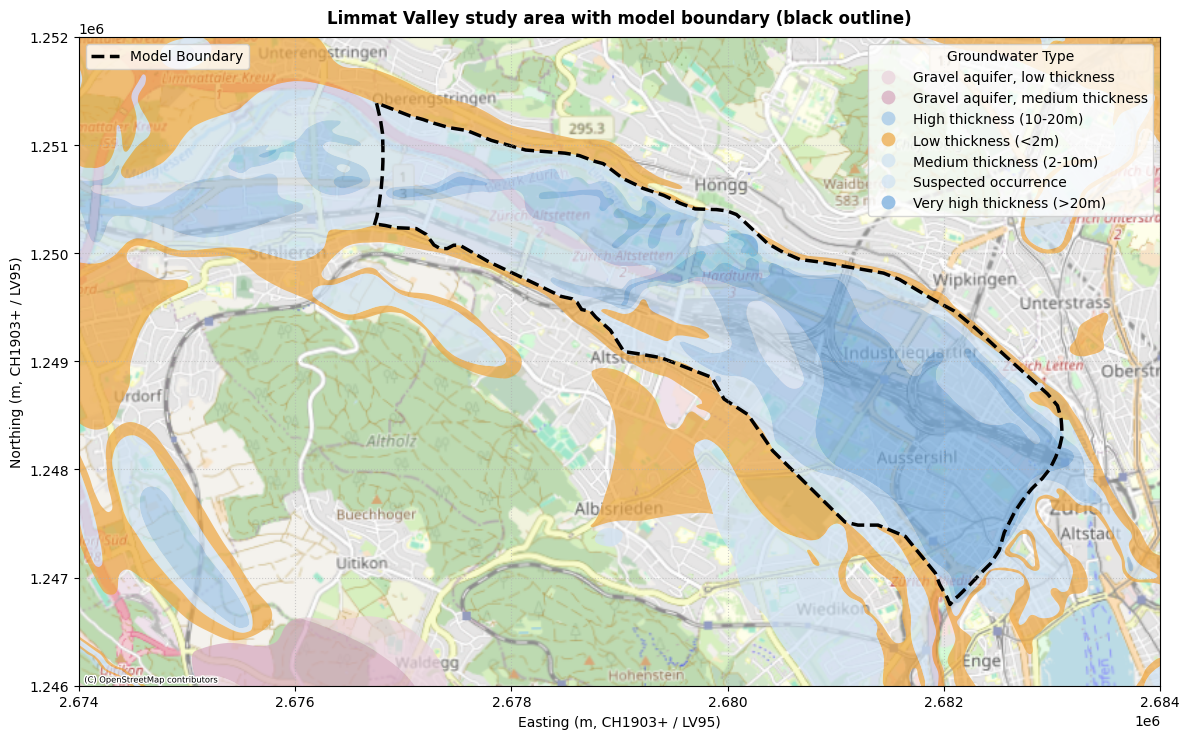

In [2]:
# Download and display study area map
gw_map_path = download_named_file(name='groundwater_map_norm', data_type='gis')
model_boundary_path = download_named_file(name='model_boundary', data_type='gis')

plot_model_area_map(
    gw_depth_path=gw_map_path,
    model_boundary_path=model_boundary_path,
    custom_title="Limmat Valley study area with model boundary (black outline)",
    basemap="osm",
    basemap_alpha=0.8
)

---

## 🎯 Model Objectives – What Are We Solving?

What exactly do we want our model to answer? Clearly defined objectives ensure your model serves a purpose and remains scientifically defensible.

### Primary Objectives

Our Limmat Valley flow model should be able to:

1. **Simulate steady-state groundwater flow** through the alluvial aquifer
2. **Reproduce observed hydraulic heads** at monitoring wells
3. **Quantify groundwater-surface water exchange** with the Limmat and Sihl rivers
4. **Evaluate the impact of pumping** on the aquifer system
5. **Support scenario analysis** for water management decisions

### Educational Objectives

As a teaching tool, the model should also:

- Demonstrate key concepts in groundwater flow modeling
- Be simple enough to understand yet realistic enough to be meaningful
- Run quickly enough for interactive exploration
- Be based on **open-source** software compatible with the JupyterHub environment
- Answer a variety of case study questions on common flow problems
- Serve as a foundation for transport modeling

<details>
<summary><strong>Optional: Exercise – Refining Model Objectives</strong></summary>

> ✏️ **Exercise: Refining Model Objectives**
> 
> Consider the objectives listed above. For a real-world consulting project:
> 
> 1. Which objectives would be most important for a water utility managing the aquifer?
> 2. What additional objectives might a regulator require?
> 3. How might objectives differ if contamination was a concern?
>
> **Hint:** Think about what each stakeholder is legally responsible for and what decisions they need to make.

</details>

---

## 🗺️ Setting the Scene – Where and When?

Models don't exist in a vacuum. Choose a meaningful spatial and temporal scale.

### Spatial Scale

| Dimension | Value | Rationale |
|-----------|-------|----------|
| **Domain extent** | ~15 km along valley | Covers the main aquifer from Zürich to downstream |
| **Width** | 1-3 km | Follows valley boundaries |
| **Depth** | ~50 m | Captures the main productive aquifer |
| **Grid resolution** | 50-100 m | Balance between detail and computation |

### Temporal Scale

| Aspect | Choice | Rationale |
|--------|--------|----------|
| **Initial focus** | Steady-state | Understand average conditions first |
| **Future extension** | Transient (daily-monthly) | For seasonal and event-based analysis |
| **Calibration period** | Multi-year average | Robust parameter estimation |

---

## Essential Data – What Do We Need?

Start compiling your data wishlist early. Check both availability and quality before committing to complex scenarios.

### Required Data Categories

| Category | Data Type | Source | Availability |
|----------|-----------|--------|-------------|
| **Geometry** | Aquifer boundaries, thickness | Geological surveys | Good |
| **Topography** | Surface DEM (digital elevation model), aquifer base | SwissTopo, boreholes | Good |
| **Hydraulic properties** | *K* (hydraulic conductivity – how easily water flows through rock), *Ss* (specific storage), *Sy* (specific yield) | AWEL (Amt für Abfall, Wasser, Energie und Luft – Cantonal Office for Waste, Water, Energy and Air), literature | Sparse |
| **Boundary conditions** | River stages, lake levels | BAFU (Bundesamt für Umwelt – Federal Office for the Environment) gauging stations | Good |
| **Stresses** | Pumping rates, recharge | Water utilities, climate data | Good |
| **Observations** | Groundwater levels | AWEL monitoring network | Good |


> **Key terms:** 
> - *K* (hydraulic conductivity): How easily water flows through the aquifer material (m/day)
> - *Ss* (specific storage): Water released from storage per unit head drop in confined aquifers (1/m)
> - *Sy* (specific yield): Drainable porosity in unconfined aquifers (dimensionless, typically 0.1–0.3)
> - *DEM*: Digital Elevation Model – a grid of surface elevations

### Data Quality Considerations

- **Temporal coverage**: Ideally 10+ years for robust calibration
- **Spatial coverage**: Are there data gaps in critical areas?
- **Consistency**: Different sources may use different datums or formats
- **Uncertainty**: What are the measurement errors?

### Comprehension Check

Before moving on, make sure you can answer this question:

> **Which data category in the table above is marked as "Sparse" and will likely need to be estimated through model calibration?**

<details>
<summary>Click to check your answer</summary>

**Hydraulic properties** (K, Ss, Sy) – These are difficult to measure directly across the entire aquifer. We typically have only a few pumping test measurements. Model calibration adjusts these values until simulated groundwater levels match observations.

This is why Step 5 (Calibration) exists in the modeling process!
</details>

---

## 👥 Key Players – Who Cares About the Results?

A model's value depends on its relevance. Understanding your end users should guide your design decisions.

### Primary Users

| Stakeholder | Interest | Model Requirements |
|-------------|----------|-------------------|
| **Students** | Learning modeling concepts | Clear, well-documented, fast |
| **Instructors** | Teaching demonstrations | Flexible, illustrative results |

<details>
<summary><strong>Optional: Real-world stakeholders</strong></summary>

### In a Real-World Context

| Stakeholder | Interest | Model Requirements |
|-------------|----------|-------------------|
| **Water utilities** | Sustainable abstraction | Drawdown predictions, safe yield |
| **Regulators** | Resource protection | Compliance scenarios, uncertainty |
| **Planners** | Development impacts | What-if scenarios, cumulative effects |
| **Public** | Water security | Clear communication of results |

</details>

---

## Summary: Flow Model Goal Definition

> **🎯 Model Objectives**
> 
> Create an educational groundwater flow model of the Limmat Valley aquifer that:
> - Simulates steady-state (and later transient) groundwater flow
> - Reproduces observed hydraulic heads
> - Quantifies groundwater-surface water interaction
> - Supports scenario analysis and teaching
>
> **🗺️ Setting the Scene**
>
> - Spatial: ~15 km valley length, 50-100 m grid resolution
> - Temporal: Steady-state initially, transient extension planned
>
> **📊 Essential Data**
>
> - Geometry and topography: Well-constrained
> - Hydraulic properties: Sparse, will require calibration
> - Boundary conditions and observations: Good coverage
>
> **👥 Key Players**
>
> - Primary: Students and instructors (educational use)
> - Secondary: Demonstrates workflow applicable to real-world users

---

## Next Steps

With our model goals clearly defined, we're ready to move on to **Step 2: The Perceptual Model**, where we'll build a detailed understanding of the Limmat Valley aquifer system — its geometry, water balance, and key processes.

**Continue to:** [2_perceptual_model.ipynb](2_perceptual_model.ipynb)